# 🤖 Phase 4 — Recommendation Models (5 Models)
## Audible Insights: Intelligent Book Recommendation System
---
### 5 Models Built:
| # | Model | Technique |
|---|---|---|
| 1 | Content-Based Filtering | TF-IDF + Cosine Similarity |
| 2 | Cluster-Based | K-Means Cluster Labels |
| 3 | Popularity-Based | Weighted Rating + Reviews |
| 4 | Genre-Based Filtering | Genre Match + Rating Rank |
| 5 | Hybrid Model | Weighted Combination of All 4 |


## 🔧 Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/eda_charts', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1f2e',
    'axes.edgecolor':   '#2e3650', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color':  '#c9d1d9',      'grid.color':  '#21262d',
    'grid.linewidth': 0.6,
})
COLORS = ['#f97316','#3b82f6','#10b981','#8b5cf6','#ec4899']
print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
df = pd.read_csv('../outputs/cleaned_data_with_clusters.csv')
df.reset_index(drop=True, inplace=True)

with open('../models/tfidf_model.pkl',  'rb') as f: tfidf        = pickle.load(f)
with open('../models/tfidf_matrix.pkl', 'rb') as f: tfidf_matrix = pickle.load(f)
with open('../models/kmeans_model.pkl', 'rb') as f: kmeans       = pickle.load(f)

# Use the most reviewed book as default test book
TEST_BOOK = df.sort_values('Number of Reviews', ascending=False).iloc[0]['Book Name']

print(f"✅ Dataset     : {df.shape[0]} books")
print(f"✅ TF-IDF      : {tfidf_matrix.shape}")
print(f"✅ Clusters    : {kmeans.n_clusters}")
print(f"✅ Test book   : '{TEST_BOOK}'")
df[['Book Name','Author','Rating','Genre','cluster']].head(4)

✅ Dataset     : 3535 books
✅ TF-IDF      : (3535, 5000)
✅ Clusters    : 23
✅ Test book   : 'The Girl On The Train'


,Book Name,Author,Rating,Genre,cluster
0,Think Like A Monk: The Secret Of How To Harnes...,Jay Shetty,4.9,Personal Success,6
1,The Subtle Art Of Not Giving A F*Ck: A Counter...,Mark Manson,4.4,Personal Success,15
2,Life'S Amazing Secrets: How To Find Balance An...,Gaur Gopal Das,4.6,Literary Essays,15
3,Sapiens,Yuval Noah Harari,4.6,History of Civilization,21


---
## 🔗 Pre-compute Cosine Similarity Matrix

In [4]:
print("Computing cosine similarity matrix...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"✅ Cosine sim matrix: {cosine_sim.shape}")

with open('../models/cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)
print("✅ Saved: models/cosine_sim.pkl")

Computing cosine similarity matrix...
✅ Cosine sim matrix: (3535, 3535)
✅ Saved: models/cosine_sim.pkl


In [5]:
def find_book(title):
    """Find book index by partial title match (case-insensitive)."""
    hits = df[df['Book Name'].str.lower().str.contains(title.lower(), na=False)]
    if hits.empty:
        return None, None
    idx = hits.index[0]
    return idx, df.loc[idx, 'Book Name']

# Test helper
idx, name = find_book("Girl On The Train")
print(f"✅ find_book test: idx={idx}, name='{name}'")

✅ find_book test: idx=60, name='The Girl On The Train'


---
## 🟠 Model 1 — Content-Based Filtering
**Logic:** Find books with the most similar descriptions using cosine similarity on TF-IDF vectors.
```
Input book → TF-IDF vector → Cosine Similarity scores → Top-N most similar books
```

In [6]:
def model1_content_based(book_title, top_n=5):
    idx, matched = find_book(book_title)
    if idx is None:
        print(f"Book '{book_title}' not found.")
        return pd.DataFrame()

    sim_scores   = list(enumerate(cosine_sim[idx]))
    sim_scores   = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_indices  = [i for i, _ in sim_scores if i != idx][:top_n]

    result = df.iloc[top_indices][['Book Name','Author','Rating','Genre','cluster']].copy()
    result.insert(0, 'Rank', range(1, len(result)+1))
    result['Similarity'] = [round(cosine_sim[idx][i], 4) for i in top_indices]
    return result.reset_index(drop=True)

print("✅ Model 1 — Content-Based defined")

✅ Model 1 — Content-Based defined


In [7]:
result1 = model1_content_based(TEST_BOOK, top_n=5)
print(f"📖 Input: '{TEST_BOOK}'")
print(f"\n🟠 Model 1 — Content-Based Recommendations:")
print(result1[['Rank','Book Name','Author','Rating','Genre','Similarity']].to_string(index=False))

📖 Input: 'The Girl On The Train'

🟠 Model 1 — Content-Based Recommendations:
 Rank                                            Book Name               Author  Rating                           Genre  Similarity
    1           I Have No Secrets: Love In Times Of Tinder       Shanaya Taneja     3.9 Adult Collections & Anthologies      0.2630
    2                                          Dark Matter         Blake Crouch     4.4                 Technothrillers      0.2033
    3                              The One You Cannot Have        Preeti Shenoy     4.3             Anthologies (Books)      0.1561
    4              Gotta Have It: 69 Stories Of Sudden Sex Rachel Kramer Bussel     3.2          Literature Anthologies      0.1279
    5 Chanakya In The Classroom: Life Lessons For Students Radhakrishnan Pillai     4.3                Personal Success      0.1242


---
## 🔵 Model 2 — Cluster-Based Recommendations
**Logic:** Find the book's cluster → return highest-rated books in that same cluster.
```
Input book → Cluster ID → All books in same cluster → Sort by Rating → Top-N
```

In [8]:
def model2_cluster_based(book_title, top_n=5):
    idx, matched = find_book(book_title)
    if idx is None:
        print(f"Book '{book_title}' not found.")
        return pd.DataFrame()

    cluster_id    = df.loc[idx, 'cluster']
    cluster_books = df[(df['cluster'] == cluster_id) & (df.index != idx)].copy()
    cluster_books = cluster_books.sort_values('Rating', ascending=False).head(top_n)
    result = cluster_books[['Book Name','Author','Rating','Genre','cluster']].copy()
    result.insert(0, 'Rank', range(1, len(result)+1))
    result.insert(len(result.columns), 'Cluster', cluster_id)
    return result.reset_index(drop=True)

print("✅ Model 2 — Cluster-Based defined")

✅ Model 2 — Cluster-Based defined


In [9]:
result2 = model2_cluster_based(TEST_BOOK, top_n=5)
idx, _ = find_book(TEST_BOOK)
cluster_id = df.loc[idx, 'cluster']
cluster_size = len(df[df['cluster'] == cluster_id])
print(f"📖 Input: '{TEST_BOOK}'")
print(f"🔵 Cluster: {cluster_id}  ({cluster_size} books in this cluster)")
print(f"\n🔵 Model 2 — Cluster-Based Recommendations:")
print(result2[['Rank','Book Name','Author','Rating','Genre']].to_string(index=False))

📖 Input: 'The Girl On The Train'
🔵 Cluster: 15  (269 books in this cluster)

🔵 Model 2 — Cluster-Based Recommendations:
 Rank                                                                      Book Name          Author  Rating             Genre
    1                            Improve Your Communication Skills: Creating Success     Alan Barker     5.0  Business Careers
    2                                                  The Ultimate Jim Rohn Library        Jim Rohn     5.0  Personal Success
    3                        50 Self-Help Classics To Guide You To Financial Freedom   Napoleon Hill     5.0  Money Management
    4                              No Calculator? No Problem!: Mastering Mental Math    Art Benjamin     5.0 Education (Books)
    5 Juliet'S School Of Possibilities: A Little Story About The Power Of Priorities Laura Vanderkam     4.9           Unknown


---
## 🟢 Model 3 — Popularity-Based Recommendations
**Logic:** Rank all books by a weighted popularity score.
```
Popularity Score = (Rating × 0.7) + (Normalized Reviews × 0.3)
```
Best for **new users** with no reading history.

In [10]:
scaler = MinMaxScaler()
df['reviews_norm']     = scaler.fit_transform(df[['Number of Reviews']])
df['popularity_score'] = (df['Rating'] * 0.7) + (df['reviews_norm'] * 0.3)

def model3_popularity_based(genre_filter=None, top_n=5):
    pool = df.copy()
    if genre_filter:
        pool = pool[pool['Genre'].str.lower().str.contains(genre_filter.lower(), na=False)]
    if pool.empty:
        print(f"No books found for genre: {genre_filter}")
        return pd.DataFrame()
    result = pool.sort_values('popularity_score', ascending=False).head(top_n)
    result = result[['Book Name','Author','Rating','Number of Reviews','Genre','popularity_score']].copy()
    result.insert(0, 'Rank', range(1, len(result)+1))
    return result.reset_index(drop=True)

print("✅ Model 3 — Popularity-Based defined")

✅ Model 3 — Popularity-Based defined


In [11]:
result3 = model3_popularity_based(top_n=5)
print(f"\n🟢 Model 3 — Top 5 Most Popular Books (Overall):")
print(result3[['Rank','Book Name','Author','Rating','Number of Reviews','popularity_score']].to_string(index=False))


🟢 Model 3 — Top 5 Most Popular Books (Overall):
 Rank                                                                                                                             Book Name         Author  Rating  Number of Reviews  popularity_score
    1                                                                                                                       The Nightingale Kristin Hannah     4.8            40958.0          3.535227
    2                                                                        F*Cking History: 111 Lessons You Should Have Learned In School    The Captain     5.0              185.0          3.500787
    3                                                                                               Raven’S Hart: Haven Hart Series, Book 7  Davidson King     5.0               37.0          3.500154
    4                                   Naked And Unafraid: 5 Keys To Abandon Smallness, Overcome Criticism, And Be All You Are Meant To Be   Kevin Ger

---
## 🟣 Model 4 — Genre-Based Filtering
**Logic:** Filter books by the same genre as the input book, rank by rating.
```
Input book → Extract Genre → Filter same genre books → Sort by Rating → Top-N
```

In [12]:
def model4_genre_based(book_title, top_n=5):
    idx, matched = find_book(book_title)
    if idx is None:
        print(f"Book '{book_title}' not found.")
        return pd.DataFrame()

    genre = df.loc[idx, 'Genre']
    if genre == 'Unknown':
        # fallback to cluster
        cid  = df.loc[idx, 'cluster']
        pool = df[(df['cluster'] == cid) & (df.index != idx)].copy()
        note = f"(Cluster {cid} — no genre)"
    else:
        pool = df[(df['Genre'] == genre) & (df.index != idx)].copy()
        note = genre

    result = pool.sort_values('Rating', ascending=False).head(top_n)
    result = result[['Book Name','Author','Rating','Genre','Number of Reviews']].copy()
    result.insert(0, 'Rank', range(1, len(result)+1))
    result.insert(len(result.columns), 'Filter', note)
    return result.reset_index(drop=True)

print("✅ Model 4 — Genre-Based defined")

✅ Model 4 — Genre-Based defined


In [13]:
result4 = model4_genre_based(TEST_BOOK, top_n=5)
idx, _ = find_book(TEST_BOOK)
genre = df.loc[idx, 'Genre']
print(f"📖 Input: '{TEST_BOOK}'")
print(f"🟣 Genre: {genre}")
print(f"\n🟣 Model 4 — Genre-Based Recommendations:")
print(result4[['Rank','Book Name','Author','Rating','Genre']].to_string(index=False))

📖 Input: 'The Girl On The Train'
🟣 Genre: Psychological Thrillers

🟣 Model 4 — Genre-Based Recommendations:
 Rank            Book Name        Author  Rating                   Genre
    1 The Girl In Room 105 Chetan Bhagat     4.3 Psychological Thrillers


---
## 🔴 Model 5 — Hybrid Model (Best Model)
**Logic:** Combine all 4 model scores into one final weighted score.
```
Hybrid Score = (Content  × 0.40)
             + (Cluster  × 0.25)
             + (Popularity × 0.20)
             + (Genre    × 0.15)
```

In [14]:
def model5_hybrid(book_title, top_n=5,
                  w_content=0.40, w_cluster=0.25,
                  w_popular=0.20, w_genre=0.15):
    idx, matched = find_book(book_title)
    if idx is None:
        print(f"Book '{book_title}' not found.")
        return pd.DataFrame()

    cluster_id = df.loc[idx, 'cluster']
    genre      = df.loc[idx, 'Genre']

    candidates = df[df.index != idx].copy()

    # Score 1 — Content (cosine similarity)
    candidates['content_score'] = cosine_sim[idx][candidates.index]

    # Score 2 — Cluster (1 if same cluster)
    candidates['cluster_score'] = (candidates['cluster'] == cluster_id).astype(float)

    # Score 3 — Popularity (normalized)
    pop_range = df['popularity_score'].max() - df['popularity_score'].min() + 1e-9
    candidates['pop_score'] = (candidates['popularity_score'] - df['popularity_score'].min()) / pop_range

    # Score 4 — Genre (1 if same genre)
    if genre != 'Unknown':
        candidates['genre_score'] = (candidates['Genre'] == genre).astype(float)
    else:
        candidates['genre_score'] = 0.0

    # Final weighted hybrid score
    candidates['hybrid_score'] = (
        candidates['content_score'] * w_content +
        candidates['cluster_score'] * w_cluster +
        candidates['pop_score']     * w_popular +
        candidates['genre_score']   * w_genre
    )

    result = candidates.sort_values('hybrid_score', ascending=False).head(top_n)
    result = result[['Book Name','Author','Rating','Genre',
                     'content_score','cluster_score','genre_score','hybrid_score']].copy()
    result = result.round(4)
    result.insert(0, 'Rank', range(1, len(result)+1))
    return result.reset_index(drop=True)

print("✅ Model 5 — Hybrid defined")

✅ Model 5 — Hybrid defined


In [15]:
result5 = model5_hybrid(TEST_BOOK, top_n=5)
print(f"📖 Input: '{TEST_BOOK}'")
print(f"\n🔴 Model 5 — Hybrid Recommendations:")
print(result5[['Rank','Book Name','Author','Rating','Genre','hybrid_score']].to_string(index=False))

📖 Input: 'The Girl On The Train'

🔴 Model 5 — Hybrid Recommendations:
 Rank                                                                              Book Name                  Author  Rating                Genre  hybrid_score
    1                                                                            Dark Matter            Blake Crouch     4.4      Technothrillers        0.5007
    2                       The Diabetes Code: Prevent And Reverse Type 2 Diabetes Naturally          Dr. Jason Fung     4.7             Diabetes        0.4743
    3                                                                You Are The Best Friend           Ajay K Pandey     4.6  Anthologies (Books)        0.4742
    4 Good Morning, Good Life: 5 Simple Habits To Master Your Mornings And Upgrade Your Life Amy Schmittauer Landino     4.7      Time Management        0.4708
    5                               Driven By Eternity: Make Your Life Count Today & Forever             John Bevere     4.7 Chris

---
## 🎯 Scenario-Based Questions

### Scenario 1 — New user likes Science Fiction → Top 5 recommendations
### Scenario 2 — User rated Thrillers highly → Similar book recommendations
### Scenario 3 — Identify Hidden Gems (high rated, low popularity)

In [16]:
# ── Scenario 1: Science Fiction ──
print("=" * 65)
print("  SCENARIO 1: New User Likes Science Fiction")
print("=" * 65)

sci_pool = df[df['Genre'].str.lower().str.contains(
    'science|fiction|fantasy|sci-fi|dystopian', na=False)].copy()

sci_recs = sci_pool.sort_values('popularity_score', ascending=False).head(5)
print(f"\nFound {len(sci_pool)} Sci-Fi / Fiction related books")
print(f"\n🚀 Top 5 Science Fiction Recommendations:")
print(sci_recs[['Book Name','Author','Rating','Number of Reviews','Genre']].to_string(index=False))

  SCENARIO 1: New User Likes Science Fiction

Found 354 Sci-Fi / Fiction related books

🚀 Top 5 Science Fiction Recommendations:
                                                     Book Name             Author  Rating  Number of Reviews                           Genre
                                               The Nightingale     Kristin Hannah     4.8            40958.0 World War II Historical Fiction
            Fighting For You: Bragan University Series, Book 2    Gianna Gabriela     5.0               11.0                  Sports Fiction
                 Boo Aur Anya Kahaniyan [Bu And Other Stories] Saadat Hasan Manto     5.0                5.0           Fiction Short Stories
                              Ramayana: An Ancient Indian Epic         Ayur Pulle     5.0                4.0              Fairy Tale Fantasy
Destiny In Flames: Hidden Realms Of Silver Lake Series, Book 4          Vella Day     5.0                4.0                 Fantasy Romance


In [17]:
# ── Scenario 2: Thriller user ──
print("=" * 65)
print("  SCENARIO 2: User Has Rated Thrillers Highly")
print("=" * 65)

thriller_pool = df[df['Genre'].str.lower().str.contains(
    'thriller|mystery|crime|suspense|detective', na=False)]

if not thriller_pool.empty:
    seed = thriller_pool.sort_values('Rating', ascending=False).iloc[0]['Book Name']
else:
    seed = TEST_BOOK

print(f"\nSeed book (top rated thriller): '{seed}'")
result_s2 = model5_hybrid(seed[:40], top_n=5)
print(f"\n🔪 Top 5 Recommendations for Thriller Fan (Hybrid Model):")
print(result_s2[['Rank','Book Name','Author','Rating','Genre','hybrid_score']].to_string(index=False))

  SCENARIO 2: User Has Rated Thrillers Highly

Seed book (top rated thriller): 'Blasphemy: The Trial Of Danesh Masih'

🔪 Top 5 Recommendations for Thriller Fan (Hybrid Model):
 Rank                                 Book Name           Author  Rating                               Genre  hybrid_score
    1   Trunk Music: Harry Bosch Series, Book 5 Michael Connelly     4.7                     Legal Thrillers        0.5937
    2                            The Last Juror     John Grisham     4.5                     Legal Thrillers        0.5798
    3                             The Associate     John Grisham     4.1                     Legal Thrillers        0.5532
    4 City Of Ashes: Mortal Instruments, Book 2  Cassandra Clare     4.7                             Unknown        0.4938
    5                   Starry River Of The Sky        Grace Lin     4.9 Fairy Tale Adaptations for Children        0.4818


In [18]:
# ── Scenario 3: Hidden Gems ──
print("=" * 65)
print("  SCENARIO 3: Hidden Gems — High Rating, Low Popularity")
print("=" * 65)

reviews_median    = df['Number of Reviews'].median()
rating_threshold  = 4.5

hidden_gems = df[
    (df['Rating'] >= rating_threshold) &
    (df['Number of Reviews'] < reviews_median)
].sort_values('Rating', ascending=False)

print(f"\nCriteria : Rating >= {rating_threshold}  AND  Reviews < {reviews_median:.0f} (median)")
print(f"Found    : {len(hidden_gems)} hidden gems")
print(f"\n💎 Top 10 Hidden Gems:")
print(hidden_gems[['Book Name','Author','Rating','Number of Reviews','Genre']]
      .head(10).to_string(index=False))

  SCENARIO 3: Hidden Gems — High Rating, Low Popularity

Criteria : Rating >= 4.5  AND  Reviews < 258 (median)
Found    : 913 hidden gems

💎 Top 10 Hidden Gems:
                                                                                                                                             Book Name                       Author  Rating  Number of Reviews                     Genre
                                                                                                                              Eighty Days To Elsewhere                      Kc Dyer     5.0                1.0                   Unknown
                                                                                                         The History Of The United States, 2Nd Edition            The Great Courses     5.0                5.0                   Unknown
                                                                                                     No Calculator? No Problem!: Mastering M

---
## 📊 Model Evaluation — Comparing All 5 Models
**Precision@5**: Of top-5 recommendations, how many share the same genre/cluster as the input book?

In [19]:
def evaluate_all_models(sample_n=40, top_n=5):
    sample_books = df[df['Genre'] != 'Unknown'].sample(
        min(sample_n, len(df)), random_state=42)

    results = {m: {'precisions': [], 'coverages': []}
               for m in ['Content','Cluster','Popularity','Genre','Hybrid']}

    for _, row in sample_books.iterrows():
        title   = row['Book Name']
        genre   = row['Genre']
        cluster = row['cluster']
        short   = title[:40]

        try:
            # Model 1
            r1 = model1_content_based(short, top_n)
            if not r1.empty and 'Genre' in r1.columns:
                results['Content']['precisions'].append((r1['Genre']==genre).mean())
                results['Content']['coverages'].append(1.0)
        except: pass

        try:
            # Model 2
            r2 = model2_cluster_based(short, top_n)
            if not r2.empty and 'Genre' in r2.columns:
                results['Cluster']['precisions'].append((r2['Genre']==genre).mean())
                results['Cluster']['coverages'].append(1.0)
        except: pass

        try:
            # Model 3
            r3 = model3_popularity_based(top_n=top_n)
            if not r3.empty and 'Genre' in r3.columns:
                results['Popularity']['precisions'].append((r3['Genre']==genre).mean())
                results['Popularity']['coverages'].append(1.0)
        except: pass

        try:
            # Model 4
            r4 = model4_genre_based(short, top_n)
            if not r4.empty and 'Genre' in r4.columns:
                results['Genre']['precisions'].append((r4['Genre']==genre).mean())
                results['Genre']['coverages'].append(1.0)
        except: pass

        try:
            # Model 5
            r5 = model5_hybrid(short, top_n)
            if not r5.empty and 'Genre' in r5.columns:
                results['Hybrid']['precisions'].append((r5['Genre']==genre).mean())
                results['Hybrid']['coverages'].append(1.0)
        except: pass

    rows = []
    for model, vals in results.items():
        rows.append({
            'Model':       model,
            'Precision@5': round(np.mean(vals['precisions']), 4) if vals['precisions'] else 0,
            'Samples':     len(vals['precisions'])
        })
    return pd.DataFrame(rows)

print("Evaluating all 5 models on 40 sample books...")
eval_df = evaluate_all_models(sample_n=40, top_n=5)
print("\n✅ Evaluation complete!")
print(eval_df.to_string(index=False))

Evaluating all 5 models on 40 sample books...
Book 'Why Suffering?: Finding Meaning And Comf' not found.
Book 'Why Suffering?: Finding Meaning And Comf' not found.
Book 'Why Suffering?: Finding Meaning And Comf' not found.
Book 'Why Suffering?: Finding Meaning And Comf' not found.
Book 'Where Are The Customers' Yachts?: Or A G' not found.
Book 'Where Are The Customers' Yachts?: Or A G' not found.
Book 'Where Are The Customers' Yachts?: Or A G' not found.
Book 'Where Are The Customers' Yachts?: Or A G' not found.

✅ Evaluation complete!
     Model  Precision@5  Samples
   Content       0.0211       38
   Cluster       0.0053       38
Popularity       0.0000       40
     Genre       0.9643       28
    Hybrid       0.1842       38


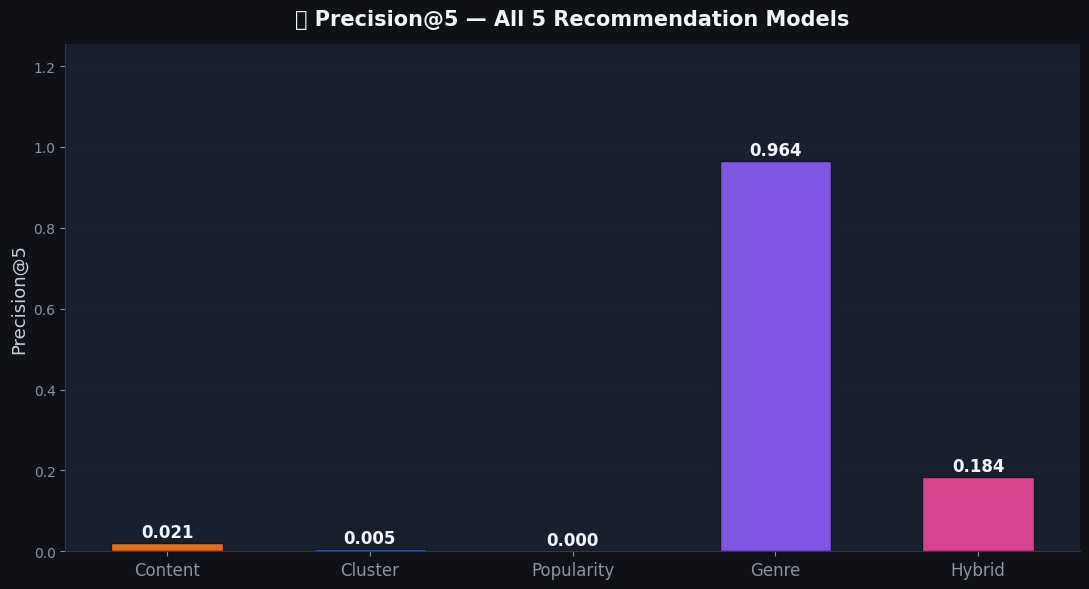


🏆 Best Model by Precision@5: Genre


In [20]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1f2e')

bars = ax.bar(eval_df['Model'], eval_df['Precision@5'],
              color=COLORS, edgecolor='#0f1117', alpha=0.9, width=0.55)
for bar, val in zip(bars, eval_df['Precision@5']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=12, color='#f1f5f9', fontweight='bold')

ax.set_title('📊 Precision@5 — All 5 Recommendation Models',
             fontsize=15, fontweight='bold', color='#f1f5f9', pad=14)
ax.set_ylabel('Precision@5', fontsize=13)
ax.set_ylim(0, max(eval_df['Precision@5'].max() * 1.3, 0.1))
ax.tick_params(axis='x', labelsize=12)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../outputs/eda_charts/13_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

best = eval_df.loc[eval_df['Precision@5'].idxmax(), 'Model']
print(f"\n🏆 Best Model by Precision@5: {best}")

---
## 🆚 Side-by-Side — Same Book Through All 5 Models

In [21]:
print(f"📖 Input Book: '{TEST_BOOK}'")
print("=" * 65)

for label, result in [
    ("🟠 Model 1 — Content-Based",    model1_content_based(TEST_BOOK, 5)),
    ("🔵 Model 2 — Cluster-Based",    model2_cluster_based(TEST_BOOK, 5)),
    ("🟢 Model 3 — Popularity-Based", model3_popularity_based(top_n=5)),
    ("🟣 Model 4 — Genre-Based",      model4_genre_based(TEST_BOOK, 5)),
    ("🔴 Model 5 — Hybrid",           model5_hybrid(TEST_BOOK, 5)),
]:
    print(f"\n{label}:")
    cols = [c for c in ['Rank','Book Name','Author','Rating','Genre'] if c in result.columns]
    print(result[cols].to_string(index=False))
    print("-" * 65)

📖 Input Book: 'The Girl On The Train'

🟠 Model 1 — Content-Based:
 Rank                                            Book Name               Author  Rating                           Genre
    1           I Have No Secrets: Love In Times Of Tinder       Shanaya Taneja     3.9 Adult Collections & Anthologies
    2                                          Dark Matter         Blake Crouch     4.4                 Technothrillers
    3                              The One You Cannot Have        Preeti Shenoy     4.3             Anthologies (Books)
    4              Gotta Have It: 69 Stories Of Sudden Sex Rachel Kramer Bussel     3.2          Literature Anthologies
    5 Chanakya In The Classroom: Life Lessons For Students Radhakrishnan Pillai     4.3                Personal Success
-----------------------------------------------------------------

🔵 Model 2 — Cluster-Based:
 Rank                                                                      Book Name          Author  Rating            

---
## 📌 Medium Q3 — Effect of Author Popularity on Ratings

In [22]:
author_stats = df.groupby('Author').agg(
    book_count    = ('Book Name','count'),
    avg_rating    = ('Rating','mean'),
    total_reviews = ('Number of Reviews','sum')
).reset_index()

author_stats['popularity_tier'] = pd.qcut(
    author_stats['total_reviews'], q=4,
    labels=['Low','Medium-Low','Medium-High','High'])

corr = author_stats['total_reviews'].corr(author_stats['avg_rating'])
tier_avg = author_stats.groupby('popularity_tier', observed=True)['avg_rating'].mean()

print(f"Correlation (total_reviews vs avg_rating): {corr:.4f}")
print("\nAvg Rating by Author Popularity Tier:")
print(tier_avg.to_string())

Correlation (total_reviews vs avg_rating): 0.0515

Avg Rating by Author Popularity Tier:
popularity_tier
Low            4.308287
Medium-Low     4.468760
Medium-High    4.501839
High           4.513429


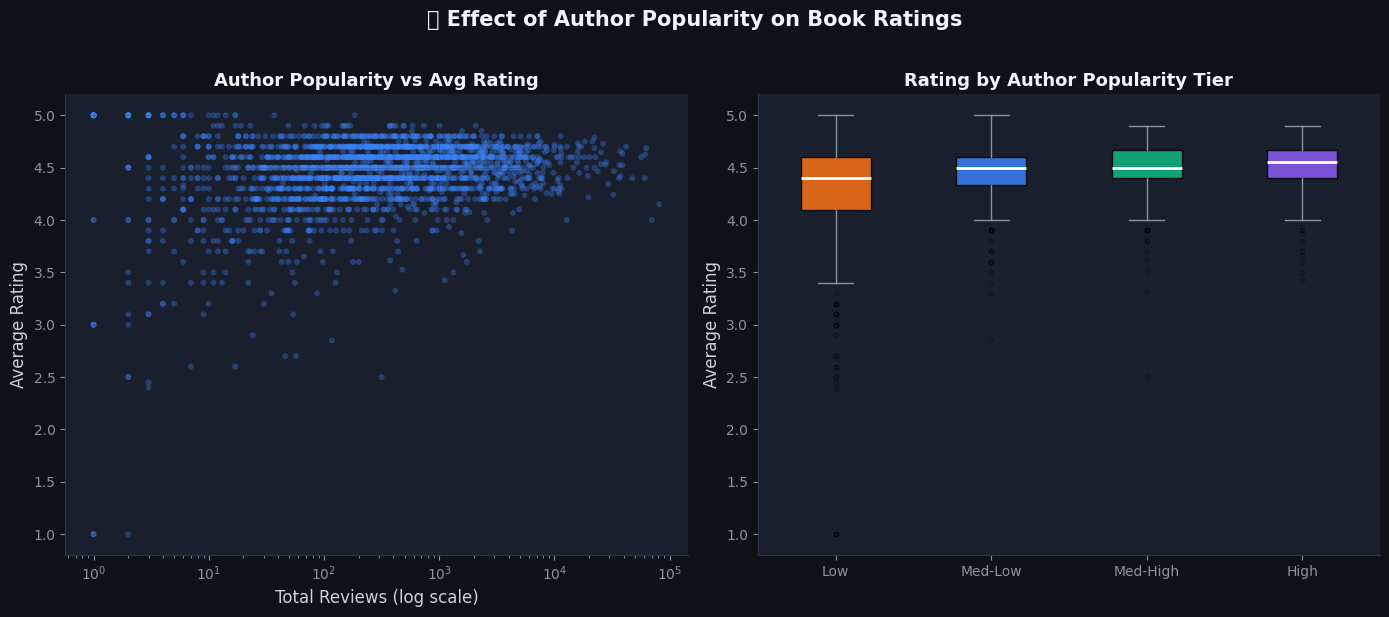

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

ax1 = axes[0]; ax1.set_facecolor('#1a1f2e')
ax1.scatter(author_stats['total_reviews'], author_stats['avg_rating'],
            alpha=0.35, s=18, color='#3b82f6', edgecolors='none')
ax1.set_xscale('log')
ax1.set_xlabel('Total Reviews (log scale)', fontsize=12)
ax1.set_ylabel('Average Rating', fontsize=12)
ax1.set_title('Author Popularity vs Avg Rating', fontsize=13,
              fontweight='bold', color='#f1f5f9')
ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True, alpha=0.3); ax1.yaxis.grid(True, alpha=0.3)

ax2 = axes[1]; ax2.set_facecolor('#1a1f2e')
tier_data = [author_stats[author_stats['popularity_tier']==t]['avg_rating'].dropna()
             for t in ['Low','Medium-Low','Medium-High','High']]
bp = ax2.boxplot(tier_data, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#8b949e'),
                 capprops=dict(color='#8b949e'),
                 flierprops=dict(marker='o', alpha=0.3, markersize=3, color='#8b949e'))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax2.set_xticklabels(['Low','Med-Low','Med-High','High'], fontsize=10)
ax2.set_ylabel('Average Rating', fontsize=12)
ax2.set_title('Rating by Author Popularity Tier', fontsize=13,
              fontweight='bold', color='#f1f5f9')
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

fig.suptitle('👤 Effect of Author Popularity on Book Ratings',
             fontsize=15, fontweight='bold', color='#f1f5f9', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/14_author_popularity.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 💾 Save All Models

In [24]:
engine = {
    'model1': model1_content_based,
    'model2': model2_cluster_based,
    'model3': model3_popularity_based,
    'model4': model4_genre_based,
    'model5': model5_hybrid,
    'eval':   eval_df,
}
with open('../models/recommendation_engine.pkl', 'wb') as f:
    pickle.dump(engine, f)

df.to_csv('../outputs/cleaned_data_with_clusters.csv', index=False)

sample_out = model5_hybrid(TEST_BOOK, top_n=10)
sample_out.to_csv('../outputs/recommendations_sample.csv', index=False)

print("✅ models/cosine_sim.pkl")
print("✅ models/recommendation_engine.pkl")
print("✅ outputs/cleaned_data_with_clusters.csv")
print("✅ outputs/recommendations_sample.csv")
print("\n📦 All models saved successfully!")

✅ models/cosine_sim.pkl
✅ models/recommendation_engine.pkl
✅ outputs/cleaned_data_with_clusters.csv
✅ outputs/recommendations_sample.csv

📦 All models saved successfully!


---
## 📋 Phase 4 Summary

In [25]:
print("=" * 65)
print("  PHASE 4 — 5 RECOMMENDATION MODELS COMPLETE")
print("=" * 65)
print()
print("🤖 Models Built:")
models_info = [
    ("Model 1","Content-Based",   "TF-IDF + Cosine Similarity"),
    ("Model 2","Cluster-Based",   "K-Means Cluster Labels"),
    ("Model 3","Popularity-Based","Weighted Rating + Reviews"),
    ("Model 4","Genre-Based",     "Genre Filter + Rating Rank"),
    ("Model 5","Hybrid",          "Weighted Combination of All 4"),
]
for m, name, tech in models_info:
    print(f"   {m} — {name:<20}: {tech}")
print()
print("📊 Evaluation (Precision@5):")
print(eval_df[['Model','Precision@5','Samples']].to_string(index=False))
best = eval_df.loc[eval_df['Precision@5'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best}")
print()
print("🎯 Scenarios:")
print("   Scenario 1 — Sci-Fi user    → Model 4 (Genre) + Model 3 (Popularity)")
print("   Scenario 2 — Thriller user  → Model 5 (Hybrid)")
print("   Scenario 3 — Hidden gems    → Rating >= 4.5 AND Reviews < median")
print()
print("=" * 65)
print("  PHASE 4 COMPLETE ✅  →  Ready for Phase 5: Streamlit App!")
print("=" * 65)

  PHASE 4 — 5 RECOMMENDATION MODELS COMPLETE

🤖 Models Built:
   Model 1 — Content-Based       : TF-IDF + Cosine Similarity
   Model 2 — Cluster-Based       : K-Means Cluster Labels
   Model 3 — Popularity-Based    : Weighted Rating + Reviews
   Model 4 — Genre-Based         : Genre Filter + Rating Rank
   Model 5 — Hybrid              : Weighted Combination of All 4

📊 Evaluation (Precision@5):
     Model  Precision@5  Samples
   Content       0.0211       38
   Cluster       0.0053       38
Popularity       0.0000       40
     Genre       0.9643       28
    Hybrid       0.1842       38

🏆 Best Model: Genre

🎯 Scenarios:
   Scenario 1 — Sci-Fi user    → Model 4 (Genre) + Model 3 (Popularity)
   Scenario 2 — Thriller user  → Model 5 (Hybrid)
   Scenario 3 — Hidden gems    → Rating >= 4.5 AND Reviews < median

  PHASE 4 COMPLETE ✅  →  Ready for Phase 5: Streamlit App!
